<a href="https://colab.research.google.com/github/fabiacamile/product-matching/blob/main/TCC_Product_Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparação de Abordagens Unimodais e Multimodais para Product Matching em E-commerce
## Versão final do TCC — implementação completa

**Aluna:** Fabia Camile dos Santos · **Orientador:** Wallace Gusmão Ferreira · **Curso:** MBA em Data Science e Analytics – USP/Esalq

Este notebook reúne todos os modelos do trabalho e a avaliação computacional:

| Grupo | Modelo | Treinamento |
|---|---|---|
| Baseline | TF-IDF + cosseno | ajuste do vocabulário |
| Baseline visual | pHash (hash perceptual fornecido no dataset) | nenhum |
| Unimodal – texto | Sentence-BERT `all-MiniLM-L6-v2` (e variante multilíngue) | nenhum (pré-treinado) |
| Unimodal – imagem | ResNet50 Siamese + Contrastive Loss (etapa preliminar) | 3 épocas (limitação de GPU) |
| Unimodal – imagem | ResNet50 ImageNet congelada | nenhum |
| Unimodal – imagem | CLIP ViT-B/32 (codificador de imagem) | nenhum |
| **Multimodal** | Fusão tardia ponderada SBERT + CLIP-imagem | peso α e limiar |
| **Multimodal** | CLIP texto + CLIP imagem (mesmo modelo) | limiar |
| **Multimodal** | Empilhamento (regressão logística sobre todas as similaridades) | regressão logística |
| Multimodal de baixo custo | TF-IDF + pHash | regressão logística |

### Dois protocolos de avaliação
* **P1 – protocolo original**: 10.000 pares positivos + 10.000 negativos **aleatórios**, divisão 80/20 estratificada. Mantido para continuidade das etapas preliminares.
* **P2 – novo protocolo**: divisão **por grupo de produto** (produtos do teste nunca vistos no treino) e metade dos negativos são **negativos difíceis** (produto mais parecido de outro grupo, minerado por TF-IDF de caracteres). Inspirado nos *corner cases* e entidades não vistas do benchmark WDC Products (Peeters et al., 2024).

### Correção metodológica em relação à etapa preliminar
* O limiar passa a ser buscado em **toda a faixa de escores do treino** (201 quantis).
* O modelo de imagem passa a ter **limiar otimizado no treino** (antes: 0,5 fixo).
* Todas as métricas de F1 recebem **intervalo de confiança bootstrap de 95%** e as comparações entre modelos usam o **teste de McNemar**.

## 1. Ambiente

In [2]:
# Instalação
import sys, subprocess
if 'google.colab' in sys.modules:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'sentence-transformers', 'statsmodels', 'psutil'], check=False)

In [3]:
import os, gc, json, time, shutil, warnings, hashlib
from concurrent.futures import ThreadPoolExecutor
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GroupShuffleSplit, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_auc_score
from statsmodels.stats.contingency_tables import mcnemar
import psutil

SEED = 42
np.random.seed(SEED)
IN_COLAB = 'google.colab' in sys.modules

try:
    import torch
    TEM_TORCH = True
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    torch.manual_seed(SEED)
except ImportError:
    TEM_TORCH, DEVICE = False, 'cpu'
print('Dispositivo:', DEVICE)
if DEVICE == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0), f'| memória: {torch.cuda.get_device_properties(0).total_memory/2**30:.1f} GiB')

Dispositivo: cuda
GPU: Tesla T4 | memória: 14.6 GiB


## 2. Configuração de caminhos e do que será executado

In [4]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/TCC - product matching/shopee-product-matching'
DATA_PATH = os.path.join(BASE_PATH, 'train.csv')
IMAGE_PATH_DRIVE = os.path.join(BASE_PATH, 'train_images')
OUT_DIR = os.path.join(BASE_PATH, 'resultados_versao_final')
EMB_DIR = os.path.join(OUT_DIR, 'embeddings')
FIG_DIR = os.path.join(OUT_DIR, 'figuras')

RUN = {
    'SBERT': True,                 # all-MiniLM-L6-v2 (mesmo modelo da etapa preliminar)
    'SBERT_MULTILINGUE': True,     # paraphrase-multilingual-MiniLM-L12-v2
    'CLIP': True,                  # clip-ViT-B-32: imagem e texto
    'RESNET_CONGELADA': True,      # ResNet50 ImageNet sem ajuste fino
    'RESNET_SIAMESE': 'carregar_ou_treinar',   # 'carregar_ou_treinar' | 'somente_carregar' | 'pular'
}
RESNET_EPOCHS = 3
COPY_IMAGES_LOCAL = True   # copiar imagens do Drive para o disco da VM
BATCH_TXT, BATCH_IMG = 128, 64

Mounted at /content/drive


In [5]:
for d in (OUT_DIR, EMB_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

local = '/content/train_images'
IMAGE_PATH = IMAGE_PATH_DRIVE   # reserva: ler direto do Drive

# Encontra o zip na raiz do "Meu Drive"; procura também na pasta do projeto
DRIVE_RAIZ = '/content/drive/MyDrive'
candidatos = [os.path.join(DRIVE_RAIZ, 'shopee-product-matching.zip'),
              os.path.join(BASE_PATH, 'shopee-product-matching.zip')]
ZIP_DRIVE = next((z for z in candidatos if os.path.exists(z)), None)
print('Zip encontrado em:', ZIP_DRIVE)

if IN_COLAB and COPY_IMAGES_LOCAL and ZIP_DRIVE:
    n_local = len(os.listdir(local)) if os.path.exists(local) else 0
    if n_local < 32000:
        t0 = time.time()
        print('Copiando o zip do Drive para o disco local...')
        shutil.copy(ZIP_DRIVE, '/content/imagens.zip')
        print(f'Cópia: {time.time()-t0:.0f} s')
        t1 = time.time()
        subprocess.run(['unzip', '-q', '-o', '/content/imagens.zip', 'train_images/*', '-d', '/content/'], check=False)
        os.remove('/content/imagens.zip')   # libera espaço no disco da VM
        print(f'Descompactação: {time.time()-t1:.0f} s')
    IMAGE_PATH = local
elif IN_COLAB and COPY_IMAGES_LOCAL:
    print('Zip não encontrado — lendo as imagens direto do Drive (mais lento).')

# Verificação de qualidade: todas as imagens referenciadas no train.csv precisam existir
_df_chk = pd.read_csv(DATA_PATH, usecols=['image'])
faltando = [f for f in _df_chk.image.unique() if not os.path.exists(os.path.join(IMAGE_PATH, f))]
TEM_IMAGENS = len(faltando) == 0
print(f'Imagens em uso: {IMAGE_PATH} | arquivos: {len(os.listdir(IMAGE_PATH)):,} | ausentes: {len(faltando)}')
assert TEM_IMAGENS, 'Há imagens faltando — confira se o upload do zip terminou antes de seguir.'

Zip encontrado em: /content/drive/MyDrive/shopee-product-matching.zip
Copiando o zip do Drive para o disco local...
Cópia: 29 s
Descompactação: 21 s
Imagens em uso: /content/train_images | arquivos: 32,412 | ausentes: 0


## 3. Utilitários: medição de custo computacional, métricas, limiar e testes estatísticos

In [7]:
class Medidor:
    """Mede tempo de parede, pico de memória de GPU e incremento de RAM de um bloco de código."""
    def __init__(self, nome): self.nome = nome
    def __enter__(self):
        gc.collect()
        if DEVICE == 'cuda':
            torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
        self.ram0 = psutil.Process().memory_info().rss
        self.t0 = time.perf_counter()
        return self
    def __exit__(self, *a):
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        self.seg = time.perf_counter() - self.t0
        self.vram_pico_mb = torch.cuda.max_memory_allocated()/2**20 if DEVICE == 'cuda' else 0.0
        self.ram_mb = max(0.0, (psutil.Process().memory_info().rss - self.ram0)/2**20)

_arq_custo = os.path.join(OUT_DIR, 'custo_computacional.json')
CUSTO = json.load(open(_arq_custo)) if os.path.exists(_arq_custo) else {}   # persiste entre sessões

def registrar_custo(modelo, **kw):
    CUSTO.setdefault(modelo, {}).update(kw)
    json.dump(CUSTO, open(os.path.join(OUT_DIR, 'custo_computacional.json'), 'w'), indent=1)

def n_parametros(m):
    try:
        return sum(p.numel() for p in m.parameters())
    except Exception:
        return None

def melhor_limiar(scores, y, n=201):
    """Busca o limiar que maximiza o F1 no TREINO, em toda a faixa de escores (quantis)."""
    grade = np.unique(np.quantile(scores, np.linspace(0, 1, n)))
    f1s = [f1_score(y, (scores >= t).astype(int)) for t in grade]
    i = int(np.argmax(f1s))
    return float(grade[i]), float(f1s[i])

def ic_bootstrap_f1(y, p, B=1000, seed=SEED):
    r = np.random.default_rng(seed); n = len(y)
    v = [f1_score(y[i], p[i]) for i in (r.integers(0, n, n) for _ in range(B))]
    return float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))

RESULTADOS, PREDICOES = [], {}

def avaliar(protocolo, modelo, modalidade, s_tr, y_tr, s_te, y_te, limiar=None):
    """Limiar escolhido no treino e aplicado ao teste; registra métricas e IC95% do F1."""
    if limiar is None:
        limiar, _ = melhor_limiar(s_tr, y_tr)
    p = (s_te >= limiar).astype(int)
    lo, hi = ic_bootstrap_f1(y_te, p)
    r = dict(protocolo=protocolo, modelo=modelo, modalidade=modalidade, limiar=limiar,
             accuracy=accuracy_score(y_te, p), precision=precision_score(y_te, p, zero_division=0),
             recall=recall_score(y_te, p), f1=f1_score(y_te, p), f1_ic95_inf=lo, f1_ic95_sup=hi,
             auc_roc=roc_auc_score(y_te, s_te))
    RESULTADOS[:] = [x for x in RESULTADOS if not (x['protocolo'] == protocolo and x['modelo'] == modelo)]
    RESULTADOS.append(r); PREDICOES[(protocolo, modelo)] = p
    pd.DataFrame(RESULTADOS).to_csv(os.path.join(OUT_DIR, 'resultados_desempenho.csv'), index=False)
    print(f"[{protocolo}] {modelo:<45} F1={r['f1']:.4f} (IC95% {lo:.4f}–{hi:.4f})  AUC={r['auc_roc']:.4f}  limiar={limiar:.3f}")
    return r

def mcnemar_teste(protocolo, a, b, y):
    """Teste de McNemar entre os acertos de dois modelos."""
    ca, cb = PREDICOES[(protocolo, a)] == y, PREDICOES[(protocolo, b)] == y
    tab = [[np.sum(ca & cb), np.sum(ca & ~cb)], [np.sum(~ca & cb), np.sum(~ca & ~cb)]]
    exato = (tab[0][1] + tab[1][0]) < 50
    res = mcnemar(tab, exact=exato, correction=not exato)
    return dict(protocolo=protocolo, modelo_a=a, modelo_b=b, so_a_acerta=int(tab[0][1]), so_b_acerta=int(tab[1][0]), p_valor=float(res.pvalue))

def cos_pares(E, i1, i2):
    """Similaridade de cosseno por par a partir de embeddings já normalizados (L2)."""
    return np.einsum('ij,ij->i', E[i1].astype(np.float32), E[i2].astype(np.float32))

## 4. Dados
A análise exploratória.

In [8]:
df = pd.read_csv(DATA_PATH)
gs = df.groupby('label_group').size()
print(f'Anúncios: {len(df):,} | grupos: {gs.size:,} | tamanho médio: {gs.mean():.2f} | mediana: {gs.median():.0f} | máx.: {gs.max()}')
print(f'Grupos com 2 anúncios: {(gs==2).mean():.1%}')
print(f"Título: {df.title.str.len().mean():.2f} caracteres, {df.title.str.split().str.len().mean():.2f} palavras em média")
print(f'Imagens distintas referenciadas: {df.image.nunique():,}')
# vetor de hashes perceptuais (64 bits)
PHASH = df['image_phash'].apply(lambda h: int(h, 16)).values.astype(np.uint64)

Anúncios: 34,250 | grupos: 11,014 | tamanho médio: 3.11 | mediana: 2 | máx.: 51
Grupos com 2 anúncios: 63.4%
Título: 56.16 caracteres, 9.41 palavras em média
Imagens distintas referenciadas: 32,412


## 5. Protocolos de avaliação (pares)
**P1** reproduz a função da etapa preliminar — os resultados de TF-IDF e SBERT da etapa preliminar são reproduzidos.
**P2** usa divisão por grupos (`GroupShuffleSplit`) e negativos difíceis.

In [9]:
def create_pairs_full_dataset(df, n_positive_pairs=10000, n_negative_pairs=10000, random_state=42):
    """Função da etapa preliminar."""
    np.random.seed(random_state)
    pairs, labels = [], []
    groups = df.groupby('label_group')
    valid_groups = [g for g, items in groups if len(items) >= 2]
    c = 0
    while c < n_positive_pairs:
        gp = groups.get_group(np.random.choice(valid_groups))
        if len(gp) >= 2:
            i1, i2 = np.random.choice(gp.index, size=2, replace=False)
            pairs.append((i1, i2)); labels.append(1); c += 1
    lg = df['label_group'].to_dict(); idx = df.index.tolist(); c = 0
    while c < n_negative_pairs:
        i1, i2 = np.random.choice(idx, size=2, replace=False)
        if lg[i1] != lg[i2]:
            pairs.append((i1, i2)); labels.append(0); c += 1
    return pd.DataFrame({'idx1': [a for a, b in pairs], 'idx2': [b for a, b in pairs], 'label': labels})

def gerar_P1():
    p = create_pairs_full_dataset(df)
    tr, te = train_test_split(p, test_size=0.2, random_state=42, stratify=p['label'])
    p = pd.concat([tr.assign(split='treino'), te.assign(split='teste')])
    p['tipo'] = p.label.map({1: 'pos', 0: 'neg_aleatorio'})
    return p

def gerar_P2():
    """Divisão por grupo (produtos do teste não aparecem no treino) + negativos difíceis.
    Negativo difícil = anúncio mais parecido (TF-IDF de caracteres 3–5) pertencente a outro grupo."""
    tr_idx, te_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(df, groups=df['label_group']))
    Xc = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_features=50000).fit_transform(df.title)
    lg = df['label_group'].values
    def pares(idx, n_pos, n_hard, n_rand, seed):
        r = np.random.default_rng(seed); sub = df.iloc[idx]
        grupos = sub.groupby('label_group').indices; chaves = list(grupos.keys()); pos = []
        while len(pos) < n_pos:
            m = sub.index.values[grupos[chaves[r.integers(len(chaves))]]]
            if len(m) >= 2:
                a, b = r.choice(m, 2, replace=False); pos.append((a, b))
        ancoras = r.choice(sub.index.values, n_hard, replace=False); pool = sub.index.values; Xp = Xc[pool]; hard = []
        for s in range(0, len(ancoras), 500):
            A = ancoras[s:s+500]; S = (Xc[A] @ Xp.T).toarray()
            for i, a in enumerate(A):
                for j in np.argsort(-S[i])[:60]:
                    b = pool[j]
                    if b != a and lg[b] != lg[a]:
                        hard.append((a, b)); break
        rnd = []
        while len(rnd) < n_rand:
            a, b = r.choice(pool, 2, replace=False)
            if lg[a] != lg[b]: rnd.append((a, b))
        P = pd.DataFrame(pos + hard + rnd, columns=['idx1', 'idx2'])
        P['label'] = [1]*len(pos) + [0]*(len(hard) + len(rnd))
        P['tipo'] = ['pos']*len(pos) + ['neg_dificil']*len(hard) + ['neg_aleatorio']*len(rnd)
        return P
    return pd.concat([pares(tr_idx, 8000, 4000, 4000, 1).assign(split='treino'),
                      pares(te_idx, 2000, 1000, 1000, 2).assign(split='teste')])

PROTOCOLOS = {}
for nome, gerador in [('P1', gerar_P1), ('P2', gerar_P2)]:
    arq = os.path.join(BASE_PATH, f'pares_{nome}.csv')
    if os.path.exists(arq):
        P = pd.read_csv(arq); origem = 'arquivo fornecido'
    else:
        P = gerador(); P.to_csv(arq, index=False); origem = 'gerado agora'
    PROTOCOLOS[nome] = {'treino': P[P.split == 'treino'].reset_index(drop=True), 'teste': P[P.split == 'teste'].reset_index(drop=True)}
    print(nome, f'({origem}):', P.groupby(['split', 'tipo']).size().to_dict())

# Sanidade: P2 não pode ter produtos do teste no treino
tr2, te2 = PROTOCOLOS['P2']['treino'], PROTOCOLOS['P2']['teste']
g_tr = set(df.label_group.values[np.r_[tr2.idx1, tr2.idx2]]); g_te = set(df.label_group.values[np.r_[te2.idx1, te2.idx2]])
print('Grupos em comum entre treino e teste no P2:', len(g_tr & g_te & set(df.label_group.values[te2[te2.label==1].idx1])))

P1 (arquivo fornecido): {('teste', 'neg_aleatorio'): 2000, ('teste', 'pos'): 2000, ('treino', 'neg_aleatorio'): 8000, ('treino', 'pos'): 8000}
P2 (arquivo fornecido): {('teste', 'neg_aleatorio'): 1000, ('teste', 'neg_dificil'): 1000, ('teste', 'pos'): 2000, ('treino', 'neg_aleatorio'): 4000, ('treino', 'neg_dificil'): 4000, ('treino', 'pos'): 8000}
Grupos em comum entre treino e teste no P2: 0


## 6. Baselines: TF-IDF e pHash (CPU)

In [10]:
SIMS = {p: {} for p in PROTOCOLOS}   # SIMS[protocolo][modelo] = (s_treino, s_teste)

def y_(p, s): return PROTOCOLOS[p][s]['label'].values

for p in PROTOCOLOS:
    tr, te = PROTOCOLOS[p]['treino'], PROTOCOLOS[p]['teste']
    # mesmos hiperparâmetros da etapa preliminar; vocabulário ajustado apenas com títulos do treino
    vec = TfidfVectorizer(max_features=6000, ngram_range=(1, 2), lowercase=True, stop_words='english')
    vec.fit(pd.concat([df.title[tr.idx1], df.title[tr.idx2]]).unique())
    with Medidor('tfidf') as m:
        X = vec.transform(df.title)                 # todos os anúncios (vetores já L2-normalizados)
    s = lambda P: np.asarray(X[P.idx1.values].multiply(X[P.idx2.values]).sum(1)).ravel()
    SIMS[p]['TF-IDF'] = (s(tr), s(te))
    if p == 'P1':
        registrar_custo('TF-IDF', dispositivo='CPU', parametros=len(vec.vocabulary_), ms_por_item=1000*m.seg/len(df),
                        tempo_catalogo_s=m.seg, ram_mb=m.ram_mb, vram_pico_mb=0.0)
        avaliar(p, 'TF-IDF (grade original, limiar 0,30)', 'texto', *SIMS[p]['TF-IDF'][:1], y_(p,'treino'), SIMS[p]['TF-IDF'][1], y_(p,'teste'), limiar=0.30)
    avaliar(p, 'TF-IDF', 'texto', SIMS[p]['TF-IDF'][0], y_(p,'treino'), SIMS[p]['TF-IDF'][1], y_(p,'teste'))

    # pHash: similaridade = 1 - distância de Hamming/64
    def ph(P):
        x = np.bitwise_xor(PHASH[P.idx1.values], PHASH[P.idx2.values])
        return 1 - np.array([bin(int(v)).count('1') for v in x]) / 64
    SIMS[p]['pHash'] = (ph(tr), ph(te))
    avaliar(p, 'pHash', 'imagem', SIMS[p]['pHash'][0], y_(p,'treino'), SIMS[p]['pHash'][1], y_(p,'teste'))
registrar_custo('pHash', dispositivo='CPU', parametros=0, ms_por_item=0.0, tempo_catalogo_s=0.0, ram_mb=0.0, vram_pico_mb=0.0,
                obs='hash pré-calculado no dataset; custo de extração não incluído')

[P1] TF-IDF (grade original, limiar 0,30)          F1=0.9191 (IC95% 0.9090–0.9277)  AUC=0.9780  limiar=0.300
[P1] TF-IDF                                        F1=0.9678 (IC95% 0.9622–0.9729)  AUC=0.9780  limiar=0.096
[P1] pHash                                         F1=0.6667 (IC95% 0.6537–0.6799)  AUC=0.6799  limiar=0.250
[P2] TF-IDF                                        F1=0.7724 (IC95% 0.7590–0.7858)  AUC=0.8271  limiar=0.056
[P2] pHash                                         F1=0.6667 (IC95% 0.6530–0.6803)  AUC=0.6962  limiar=0.250


## 7. Embeddings de todos os anúncios (texto)
Cada anúncio é codificado **uma única vez**; a similaridade de um par é o produto interno dos embeddings normalizados. Os embeddings dos 34.250 anúncios são salvos no Drive.

In [11]:
EMB = {}

def carregar_ou_calcular(nome, funcao):
    """Carrega embeddings do Drive ou calcula e salva (com medição de custo)."""
    arq = os.path.join(EMB_DIR, f'{nome}.npy')
    if os.path.exists(arq):
        EMB[nome] = np.load(arq).astype(np.float32); print(nome, 'carregado do Drive', EMB[nome].shape); return
    with Medidor(nome) as m:
        E, n_par = funcao()
    E = E / np.linalg.norm(E, axis=1, keepdims=True).clip(1e-12)
    np.save(arq, E.astype(np.float16)); EMB[nome] = E.astype(np.float32)
    registrar_custo(nome, dispositivo=DEVICE.upper(), parametros=n_par, tempo_catalogo_s=m.seg,
                    ms_por_item=1000*m.seg/len(df), vram_pico_mb=m.vram_pico_mb, ram_mb=m.ram_mb)
    print(f'{nome}: {E.shape} em {m.seg:.1f} s | pico VRAM {m.vram_pico_mb:.0f} MB')

def sbert(nome_modelo):
    def f():
        from sentence_transformers import SentenceTransformer
        mdl = SentenceTransformer(nome_modelo, device=DEVICE)
        E = mdl.encode(df.title.tolist(), batch_size=BATCH_TXT, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)
        n = n_parametros(mdl); del mdl; gc.collect()
        return E, n
    return f

if RUN['SBERT']:
    carregar_ou_calcular('SBERT', sbert('sentence-transformers/all-MiniLM-L6-v2'))
if RUN['SBERT_MULTILINGUE']:
    carregar_ou_calcular('SBERT-multilíngue', sbert('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'))

SBERT carregado do Drive (34250, 384)
SBERT-multilíngue carregado do Drive (34250, 384)


## 8. Embeddings de imagem e CLIP
* **CLIP ViT-B/32** (Radford et al., 2021): codificador de imagem e de texto no mesmo espaço vetorial.
* **ResNet50 congelada** (pesos ImageNet): baseline visual sem nenhum treinamento.
Apenas os arquivos de imagem **distintos** são processados (anúncios que compartilham a mesma imagem reaproveitam o embedding).

In [12]:
from PIL import Image
IMGS_UNICAS = df.image.unique()
MAPA_IMG = {f: i for i, f in enumerate(IMGS_UNICAS)}
IDX_IMG = df.image.map(MAPA_IMG).values          # anúncio -> linha do embedding de imagem

def abrir(f):
    try:
        return Image.open(os.path.join(IMAGE_PATH, f)).convert('RGB')
    except Exception:
        return Image.new('RGB', (224, 224), 'white')   # imagem ausente/corrompida

def clip_imagem():
    from sentence_transformers import SentenceTransformer
    mdl = SentenceTransformer('clip-ViT-B-32', device=DEVICE)
    out = []
    with ThreadPoolExecutor(8) as ex:              # leitura de disco em paralelo
        for s in range(0, len(IMGS_UNICAS), 512):
            imgs = list(ex.map(abrir, IMGS_UNICAS[s:s+512]))
            out.append(mdl.encode(imgs, batch_size=BATCH_IMG, convert_to_numpy=True, normalize_embeddings=True))
            if s % 5120 == 0: print(f'  {s:,}/{len(IMGS_UNICAS):,} imagens')
    n = n_parametros(mdl); del mdl; gc.collect()
    return np.vstack(out)[IDX_IMG], n

def clip_texto():
    from sentence_transformers import SentenceTransformer
    mdl = SentenceTransformer('clip-ViT-B-32', device=DEVICE)
    # títulos são truncados em 150 caracteres
    E = mdl.encode(df.title.str.slice(0, 150).tolist(), batch_size=BATCH_TXT, convert_to_numpy=True, normalize_embeddings=True)
    n = n_parametros(mdl); del mdl; gc.collect()
    return E, n

if RUN['CLIP'] and TEM_IMAGENS:
    carregar_ou_calcular('CLIP-imagem', clip_imagem)
    carregar_ou_calcular('CLIP-texto', clip_texto)

CLIP-imagem carregado do Drive (34250, 512)
CLIP-texto carregado do Drive (34250, 512)


In [13]:
# ResNet50 congelada (ImageNet) — extrator de características sem ajuste fino
if RUN['RESNET_CONGELADA'] and TEM_IMAGENS and TEM_TORCH:
    import torchvision.models as tvm, torchvision.transforms as T
    from torch.utils.data import Dataset, DataLoader
    TF_IMG = T.Compose([T.Resize((224, 224)), T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    class DSImagens(Dataset):
        def __init__(self, arquivos): self.a = arquivos
        def __len__(self): return len(self.a)
        def __getitem__(self, i): return TF_IMG(abrir(self.a[i]))
    def resnet_congelada():
        net = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2); net.fc = torch.nn.Identity(); net = net.to(DEVICE).eval()
        dl = DataLoader(DSImagens(IMGS_UNICAS), batch_size=BATCH_IMG, num_workers=2)
        out = []
        with torch.no_grad(), torch.autocast(device_type='cuda', enabled=(DEVICE == 'cuda')):
            for x in dl: out.append(net(x.to(DEVICE)).float().cpu().numpy())
        n = n_parametros(net); del net; gc.collect()
        return np.vstack(out)[IDX_IMG], n
    carregar_ou_calcular('ResNet50-congelada', resnet_congelada)

ResNet50-congelada carregado do Drive (34250, 2048)


## 9. ResNet50 Siamese (modelo da etapa preliminar)

In [14]:
if RUN['RESNET_SIAMESE'] != 'pular' and TEM_IMAGENS and TEM_TORCH:
    import torch.nn as nn, torch.nn.functional as F
    import torchvision.models as tvm, torchvision.transforms as T
    from torch.utils.data import Dataset, DataLoader
    TF_IMG = T.Compose([T.Resize((224, 224)), T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

    class SiameseNetwork(nn.Module):
        def __init__(self, embedding_dim=128):
            super().__init__()
            r = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V1)   # equivalente a pretrained=True
            self.backbone = nn.Sequential(*list(r.children())[:-1])
            self.embedding = nn.Sequential(nn.Linear(2048, 512), nn.ReLU(), nn.Dropout(0.2), nn.Linear(512, embedding_dim))
        def forward_one(self, x):
            return F.normalize(self.embedding(self.backbone(x).flatten(1)), p=2, dim=1)
        def forward(self, a, b): return self.forward_one(a), self.forward_one(b)

    def contrastive_loss(e1, e2, y, margin=1.0):
        d = F.pairwise_distance(e1, e2)
        return (y * d.pow(2) + (1 - y) * F.relu(margin - d).pow(2)).mean()

    class DSPares(Dataset):
        def __init__(self, P): self.P = P.reset_index(drop=True)
        def __len__(self): return len(self.P)
        def __getitem__(self, i):
            r = self.P.iloc[i]
            return TF_IMG(abrir(df.image[r.idx1])), TF_IMG(abrir(df.image[r.idx2])), torch.tensor(float(r.label))

    CKPT = os.path.join(OUT_DIR, 'resnet_siamese_ckpt.pth'); BEST = os.path.join(OUT_DIR, 'resnet_siamese_best.pth')
    net = SiameseNetwork().to(DEVICE)
    if os.path.exists(BEST) and (not os.path.exists(CKPT) or torch.load(CKPT, map_location='cpu')['epoca'] >= RESNET_EPOCHS):
        net.load_state_dict(torch.load(BEST, map_location=DEVICE)); print('Modelo Siamese carregado do Drive')
        TREINADO = True
    elif RUN['RESNET_SIAMESE'] == 'carregar_ou_treinar':
        # validação separada do TREINO (10%) para escolher o melhor checkpoint
        tr1, va1 = train_test_split(PROTOCOLOS['P1']['treino'], test_size=0.1, random_state=42, stratify=PROTOCOLOS['P1']['treino'].label)
        dl_tr = DataLoader(DSPares(tr1), batch_size=32, shuffle=True, num_workers=2, drop_last=True)
        dl_va = DataLoader(DSPares(va1), batch_size=64, num_workers=2)
        opt = torch.optim.Adam(net.parameters(), lr=1e-3)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=2)
        scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE == 'cuda')) if hasattr(torch, 'amp') and hasattr(torch.amp, 'GradScaler') else torch.cuda.amp.GradScaler(enabled=(DEVICE == 'cuda'))
        ep0, best, hist = 0, float('inf'), []
        if os.path.exists(CKPT):
            ck = torch.load(CKPT, map_location=DEVICE)
            net.load_state_dict(ck['modelo']); opt.load_state_dict(ck['otimizador']); ep0, best, hist = ck['epoca'], ck['melhor'], ck['historico']
            print(f'Retomando da época {ep0}')
        t_treino = time.perf_counter()
        for ep in range(ep0, RESNET_EPOCHS):
            net.train(); tl = 0
            for a, b, y in dl_tr:
                a, b, y = a.to(DEVICE), b.to(DEVICE), y.to(DEVICE); opt.zero_grad()
                with torch.autocast(device_type='cuda', enabled=(DEVICE == 'cuda')):
                    e1, e2 = net(a, b)
                loss = contrastive_loss(e1.float(), e2.float(), y)
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); tl += loss.item()
            net.eval(); vl = 0
            with torch.no_grad(), torch.autocast(device_type='cuda', enabled=(DEVICE == 'cuda')):
                for a, b, y in dl_va:
                    e1, e2 = net(a.to(DEVICE), b.to(DEVICE)); vl += contrastive_loss(e1.float(), e2.float(), y.to(DEVICE)).item()
            tl, vl = tl/len(dl_tr), vl/len(dl_va); sched.step(vl); hist.append((ep+1, tl, vl))
            print(f'Época {ep+1}/{RESNET_EPOCHS} - perda treino {tl:.4f} - perda validação {vl:.4f}')
            if vl < best:
                best = vl; torch.save(net.state_dict(), BEST)
            torch.save({'modelo': net.state_dict(), 'otimizador': opt.state_dict(), 'epoca': ep+1, 'melhor': best, 'historico': hist}, CKPT)
        registrar_custo('ResNet50-Siamese', tempo_treino_s=time.perf_counter()-t_treino, epocas=RESNET_EPOCHS, historico=hist)
        net.load_state_dict(torch.load(BEST, map_location=DEVICE)); TREINADO = True
    else:
        TREINADO = False; print('Checkpoint não encontrado e treino desativado.')

    if TREINADO:
        class DSImg(Dataset):
            def __init__(self, a): self.a = a
            def __len__(self): return len(self.a)
            def __getitem__(self, i): return TF_IMG(abrir(self.a[i]))
        def siamese_emb():
            net.eval(); out = []
            with torch.no_grad(), torch.autocast(device_type='cuda', enabled=(DEVICE == 'cuda')):
                for x in DataLoader(DSImg(IMGS_UNICAS), batch_size=BATCH_IMG, num_workers=2):
                    out.append(net.forward_one(x.to(DEVICE)).float().cpu().numpy())
            return np.vstack(out)[IDX_IMG], n_parametros(net)
        carregar_ou_calcular('ResNet50-Siamese', siamese_emb)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


Modelo Siamese carregado do Drive
ResNet50-Siamese carregado do Drive (34250, 128)


## 10. Avaliação dos modelos unimodais (P1 e P2)

In [15]:
MODALIDADE = {'SBERT': 'texto', 'SBERT-multilíngue': 'texto', 'CLIP-texto': 'texto',
              'CLIP-imagem': 'imagem', 'ResNet50-congelada': 'imagem', 'ResNet50-Siamese': 'imagem'}
for nome, E in EMB.items():
    for p in PROTOCOLOS:
        if nome == 'ResNet50-Siamese' and p == 'P2':
            print('[P2] ResNet50-Siamese não avaliado: foi treinado com pares do P1, que contêm produtos do teste do P2 (vazamento).')
            continue
        tr, te = PROTOCOLOS[p]['treino'], PROTOCOLOS[p]['teste']
        SIMS[p][nome] = (cos_pares(E, tr.idx1.values, tr.idx2.values), cos_pares(E, te.idx1.values, te.idx2.values))
        avaliar(p, nome, MODALIDADE[nome], SIMS[p][nome][0], y_(p, 'treino'), SIMS[p][nome][1], y_(p, 'teste'))
if 'ResNet50-Siamese' in EMB:
    # comparação direta com a etapa preliminar (limiar fixo 0,5)
    avaliar('P1', 'ResNet50-Siamese (limiar fixo 0,5)', 'imagem', *SIMS['P1']['ResNet50-Siamese'][:1], y_('P1','treino'),
            SIMS['P1']['ResNet50-Siamese'][1], y_('P1','teste'), limiar=0.5)

[P1] SBERT                                         F1=0.9432 (IC95% 0.9355–0.9500)  AUC=0.9859  limiar=0.435
[P2] SBERT                                         F1=0.7919 (IC95% 0.7790–0.8039)  AUC=0.8758  limiar=0.396
[P1] SBERT-multilíngue                             F1=0.8985 (IC95% 0.8880–0.9077)  AUC=0.9595  limiar=0.406
[P2] SBERT-multilíngue                             F1=0.7818 (IC95% 0.7690–0.7947)  AUC=0.8554  limiar=0.373
[P1] CLIP-imagem                                   F1=0.9051 (IC95% 0.8952–0.9147)  AUC=0.9654  limiar=0.603
[P2] CLIP-imagem                                   F1=0.8182 (IC95% 0.8056–0.8300)  AUC=0.8991  limiar=0.604
[P1] CLIP-texto                                    F1=0.9262 (IC95% 0.9170–0.9345)  AUC=0.9769  limiar=0.698
[P2] CLIP-texto                                    F1=0.8033 (IC95% 0.7904–0.8157)  AUC=0.8722  limiar=0.687
[P1] ResNet50-congelada                            F1=0.9155 (IC95% 0.9065–0.9240)  AUC=0.9734  limiar=0.433
[P2] ResNet50-conge

## 11. Modelos multimodais
* **Fusão tardia ponderada**: $s = \alpha\, z(s_{texto}) + (1-\alpha)\, z(s_{imagem})$, com escores padronizados (z) pelo treino e $\alpha$ e limiar escolhidos no treino.
* **CLIP multimodal**: média das similaridades texto–texto e imagem–imagem do mesmo modelo CLIP.
* **Empilhamento (*stacking*)**: regressão logística sobre todas as similaridades disponíveis; o limiar é escolhido com predições de validação cruzada (5 *folds*) no treino, evitando otimismo.

In [16]:
def z(s_tr, s_te):
    mu, sd = s_tr.mean(), s_tr.std() + 1e-9
    return (s_tr - mu)/sd, (s_te - mu)/sd

def fusao_ponderada(p, a, b, nome):
    if a not in SIMS[p] or b not in SIMS[p]: return
    (at, ae), (bt, be) = z(*SIMS[p][a]), z(*SIMS[p][b]); yt = y_(p, 'treino'); melhor = None
    for al in np.linspace(0, 1, 21):
        t, f = melhor_limiar(al*at + (1-al)*bt, yt)
        if melhor is None or f > melhor[0]: melhor = (f, al, t)
    f, al, t = melhor
    r = avaliar(p, nome, 'multimodal', al*at + (1-al)*bt, yt, al*ae + (1-al)*be, y_(p, 'teste'), limiar=t)
    r['alpha_texto'] = float(al); print(f'      α (peso do texto) = {al:.2f}')

def empilhamento(p, feats, nome, clf=None):
    feats = [f for f in feats if f in SIMS[p]]
    if len(feats) < 2: return
    Xt = np.c_[tuple(SIMS[p][f][0] for f in feats)]; Xe = np.c_[tuple(SIMS[p][f][1] for f in feats)]; yt = y_(p, 'treino')
    clf = clf or make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    oof = cross_val_predict(clf, Xt, yt, cv=5, method='predict_proba')[:, 1]
    t, _ = melhor_limiar(oof, yt)
    clf.fit(Xt, yt); pe = clf.predict_proba(Xe)[:, 1]
    avaliar(p, nome, 'multimodal', oof, yt, pe, y_(p, 'teste'), limiar=t)
    if hasattr(clf[-1], 'coef_'):
        print('      coeficientes padronizados:', dict(zip(feats, np.round(clf[-1].coef_[0], 3))))

for p in PROTOCOLOS:
    fusao_ponderada(p, 'SBERT', 'CLIP-imagem', 'Multimodal: SBERT + CLIP-imagem (fusão ponderada)')
    fusao_ponderada(p, 'SBERT-multilíngue', 'CLIP-imagem', 'Multimodal: SBERT-multilíngue + CLIP-imagem')
    if 'CLIP-texto' in SIMS[p] and 'CLIP-imagem' in SIMS[p]:
        st = (SIMS[p]['CLIP-texto'][0] + SIMS[p]['CLIP-imagem'][0]) / 2; se = (SIMS[p]['CLIP-texto'][1] + SIMS[p]['CLIP-imagem'][1]) / 2
        avaliar(p, 'Multimodal: CLIP (texto + imagem)', 'multimodal', st, y_(p, 'treino'), se, y_(p, 'teste'))
    empilhamento(p, ['TF-IDF', 'pHash'], 'Multimodal baixo custo: TF-IDF + pHash')
    todas = ['TF-IDF', 'pHash', 'SBERT', 'SBERT-multilíngue', 'CLIP-texto', 'CLIP-imagem', 'ResNet50-congelada'] + (['ResNet50-Siamese'] if p == 'P1' else [])
    empilhamento(p, todas, 'Multimodal: empilhamento (regressão logística)')

[P1] Multimodal: SBERT + CLIP-imagem (fusão ponderada) F1=0.9781 (IC95% 0.9730–0.9822)  AUC=0.9972  limiar=-0.120
      α (peso do texto) = 0.60
[P1] Multimodal: SBERT-multilíngue + CLIP-imagem   F1=0.9597 (IC95% 0.9533–0.9654)  AUC=0.9918  limiar=-0.154
      α (peso do texto) = 0.45
[P1] Multimodal: CLIP (texto + imagem)             F1=0.9663 (IC95% 0.9602–0.9722)  AUC=0.9947  limiar=0.646
[P1] Multimodal baixo custo: TF-IDF + pHash        F1=0.9740 (IC95% 0.9688–0.9787)  AUC=0.9845  limiar=0.246
      coeficientes padronizados: {'TF-IDF': np.float64(8.879), 'pHash': np.float64(1.584)}
[P1] Multimodal: empilhamento (regressão logística) F1=0.9910 (IC95% 0.9880–0.9937)  AUC=0.9991  limiar=0.382
      coeficientes padronizados: {'TF-IDF': np.float64(3.712), 'pHash': np.float64(-0.197), 'SBERT': np.float64(0.95), 'SBERT-multilíngue': np.float64(0.814), 'CLIP-texto': np.float64(1.084), 'CLIP-imagem': np.float64(1.93), 'ResNet50-congelada': np.float64(2.234), 'ResNet50-Siamese': np.float6

## 12. Tabelas de desempenho e testes estatísticos

In [17]:
R = pd.DataFrame(RESULTADOS)
for p in PROTOCOLOS:
    print(f'\n===== Protocolo {p} =====')
    print(R[R.protocolo == p].sort_values('f1', ascending=False)[['modelo', 'modalidade', 'limiar', 'accuracy', 'precision', 'recall', 'f1', 'f1_ic95_inf', 'f1_ic95_sup', 'auc_roc']].round(4).to_string(index=False))

# McNemar: melhor multimodal vs melhor unimodal em cada protocolo
TESTES = []
for p in PROTOCOLOS:
    Rp = R[R.protocolo == p]; y = y_(p, 'teste')
    uni = Rp[Rp.modalidade != 'multimodal'].sort_values('f1').iloc[-1].modelo
    if (Rp.modalidade == 'multimodal').any():
        mm = Rp[Rp.modalidade == 'multimodal'].sort_values('f1').iloc[-1].modelo
        TESTES.append(mcnemar_teste(p, mm, uni, y))
    for base in ['TF-IDF']:
        if 'SBERT' in SIMS[p]: TESTES.append(mcnemar_teste(p, 'SBERT', base, y))
T_ = pd.DataFrame(TESTES); T_.to_csv(os.path.join(OUT_DIR, 'testes_mcnemar.csv'), index=False); print('\n', T_.to_string(index=False))

# Taxa de falsos positivos por tipo de negativo (P2) — mostra onde cada modelo erra
te = PROTOCOLOS['P2']['teste']; linhas = []
for (p, m), pred in PREDICOES.items():
    if p == 'P2':
        linhas.append(dict(modelo=m, FP_neg_aleatorios=pred[te.tipo.values == 'neg_aleatorio'].mean(),
                           FP_neg_dificeis=pred[te.tipo.values == 'neg_dificil'].mean(), recall=pred[te.tipo.values == 'pos'].mean()))
FP = pd.DataFrame(linhas).sort_values('FP_neg_dificeis'); FP.to_csv(os.path.join(OUT_DIR, 'erros_por_tipo_P2.csv'), index=False)
print('\n', FP.round(3).to_string(index=False))


===== Protocolo P1 =====
                                           modelo modalidade  limiar  accuracy  precision  recall     f1  f1_ic95_inf  f1_ic95_sup  auc_roc
   Multimodal: empilhamento (regressão logística) multimodal  0.3821    0.9910     0.9895  0.9925 0.9910       0.9880       0.9937   0.9991
Multimodal: SBERT + CLIP-imagem (fusão ponderada) multimodal -0.1202    0.9782     0.9828  0.9735 0.9781       0.9730       0.9822   0.9972
           Multimodal baixo custo: TF-IDF + pHash multimodal  0.2455    0.9742     0.9822  0.9660 0.9740       0.9688       0.9787   0.9845
                                           TF-IDF      texto  0.0959    0.9685     0.9890  0.9475 0.9678       0.9622       0.9729   0.9780
                Multimodal: CLIP (texto + imagem) multimodal  0.6463    0.9662     0.9651  0.9675 0.9663       0.9602       0.9722   0.9947
      Multimodal: SBERT-multilíngue + CLIP-imagem multimodal -0.1535    0.9598     0.9609  0.9585 0.9597       0.9533       0.9654   0

## 13. Avaliação computacional
Duas medidas complementares:
1. **Custo por anúncio** (codificação do catálogo inteiro) — relevante para produção, pois os embeddings são reutilizados.
2. **Tempo por par de ponta a ponta** (codificar os dois itens de cada par do teste do P1 e compará-los), na mesma definição da etapa preliminar.

Registram-se ainda o número de parâmetros, o pico de memória de GPU e o tamanho do modelo.

In [18]:
te1 = PROTOCOLOS['P1']['teste']
def tempo_por_par(nome, funcao_encode, lista1, lista2, comparar=lambda a, b: np.einsum('ij,ij->i', a, b)):
    with Medidor(nome) as m:
        e1 = funcao_encode(lista1); e2 = funcao_encode(lista2)
        _ = comparar(e1, e2)
    registrar_custo(nome, ms_por_par=1000*m.seg/len(lista1), pares_por_s=len(lista1)/m.seg, vram_pico_par_mb=m.vram_pico_mb)
    print(f'{nome:<22} {1000*m.seg/len(lista1):8.3f} ms/par | {len(lista1)/m.seg:9.1f} pares/s | pico VRAM {m.vram_pico_mb:7.0f} MB')

t1, t2 = df.title[te1.idx1].tolist(), df.title[te1.idx2].tolist()
i1, i2 = df.image[te1.idx1].tolist(), df.image[te1.idx2].tolist()

vec = TfidfVectorizer(max_features=6000, ngram_range=(1, 2), stop_words='english').fit(df.title)
tempo_por_par('TF-IDF', vec.transform, t1, t2, comparar=lambda a, b: np.asarray(a.multiply(b).sum(1)).ravel())

from importlib.util import find_spec
if find_spec('sentence_transformers'):
    from sentence_transformers import SentenceTransformer
    for nome, mid, txt in [('SBERT', 'sentence-transformers/all-MiniLM-L6-v2', True),
                           ('SBERT-multilíngue', 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', True),
                           ('CLIP-texto', 'clip-ViT-B-32', True), ('CLIP-imagem', 'clip-ViT-B-32', False)]:
        if nome not in EMB: continue
        mdl = SentenceTransformer(mid, device=DEVICE)
        registrar_custo(nome, tamanho_mb=sum(p.numel()*p.element_size() for p in mdl.parameters())/2**20)
        if txt:
            enc = lambda L: mdl.encode(L if nome != 'CLIP-texto' else [x[:150] for x in L], batch_size=BATCH_TXT, convert_to_numpy=True, normalize_embeddings=True)
            tempo_por_par(nome, enc, t1, t2)
        else:
            def enc(L):
                with ThreadPoolExecutor(8) as ex: imgs = list(ex.map(abrir, L))
                return mdl.encode(imgs, batch_size=BATCH_IMG, convert_to_numpy=True, normalize_embeddings=True)
            tempo_por_par(nome, enc, i1, i2)
        del mdl; gc.collect()
        if DEVICE == 'cuda': torch.cuda.empty_cache()

C = pd.DataFrame(CUSTO).T
# custo dos modelos multimodais = soma dos componentes
for mm, comps in {'Multimodal: SBERT + CLIP-imagem (fusão ponderada)': ['SBERT', 'CLIP-imagem'],
                  'Multimodal: CLIP (texto + imagem)': ['CLIP-texto', 'CLIP-imagem'],
                  'Multimodal baixo custo: TF-IDF + pHash': ['TF-IDF', 'pHash']}.items():
    if all(c in C.index for c in comps):
        C.loc[mm, ['ms_por_item', 'ms_por_par']] = [C.loc[comps, 'ms_por_item'].sum(), C.loc[comps, 'ms_por_par'].fillna(0).sum()]
        C.loc[mm, 'vram_pico_mb'] = C.loc[comps, 'vram_pico_mb'].max()
        C.loc[mm, 'dispositivo'] = '+'.join(sorted(set(C.loc[comps, 'dispositivo'].astype(str))))
C['projecao_catalogo_1M_min'] = C['ms_por_item'].astype(float) * 1e6 / 1000 / 60
C.to_csv(os.path.join(OUT_DIR, 'custo_computacional.csv'))
print(C.drop(columns=[c for c in ['historico'] if c in C], errors='ignore').to_string())

TF-IDF                    0.032 ms/par |   31230.1 pares/s | pico VRAM      94 MB


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP-texto                1.794 ms/par |     557.3 pares/s | pico VRAM     998 MB


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP-imagem              13.561 ms/par |      73.7 pares/s | pico VRAM     908 MB
                                                  dispositivo parametros ms_por_item tempo_catalogo_s      ram_mb vram_pico_mb ms_por_par   pares_por_s vram_pico_par_mb                                                            obs  tamanho_mb tempo_treino_s epocas  projecao_catalogo_1M_min
TF-IDF                                                    CPU       6000     0.01608         0.550731    5.804688          0.0    0.03202  31230.066678        94.164062                                                            NaN         NaN            NaN    NaN                  0.267995
pHash                                                     CPU          0         0.0              0.0         0.0          0.0        NaN           NaN              NaN  hash pré-calculado no dataset; custo de extração não incluído         NaN            NaN    NaN                  0.000000
SBERT                                     

## 14. Figuras (Trade-off acurácia × custo (P1))

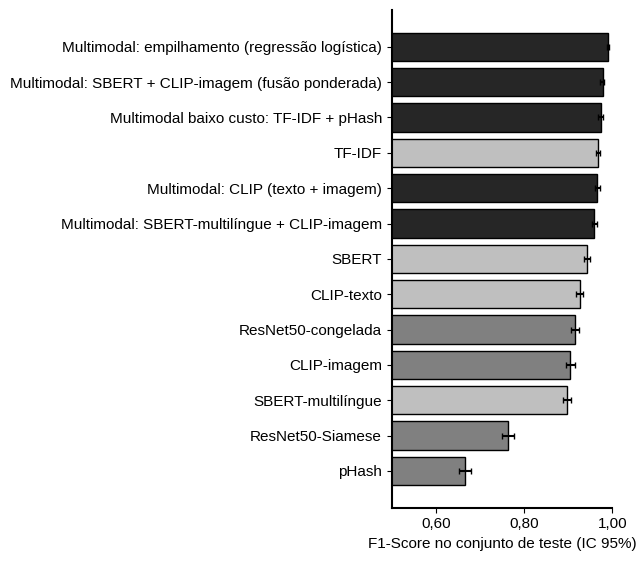

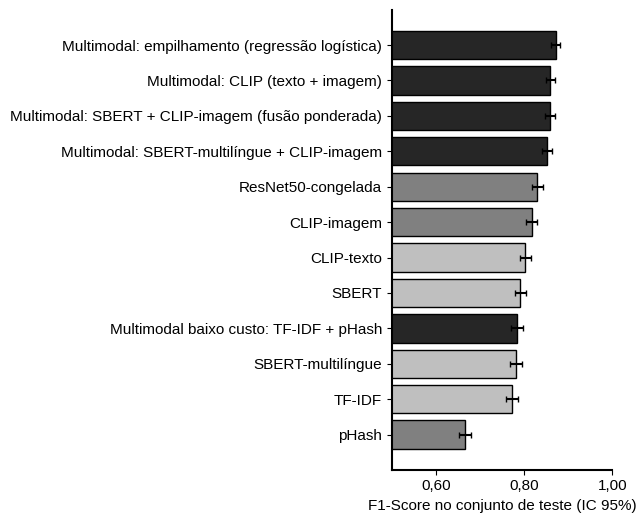

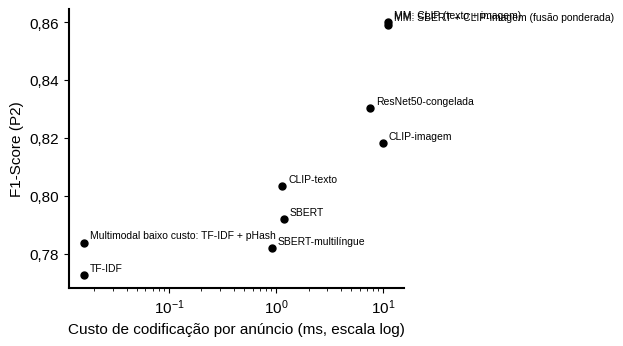

In [19]:
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Liberation Sans', 'DejaVu Sans'], 'font.size': 11,
                     'axes.linewidth': 1.5, 'axes.edgecolor': 'black', 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': False})
virg = FuncFormatter(lambda v, p: f'{v:.2f}'.replace('.', ','))
R = pd.DataFrame(RESULTADOS)
for p in PROTOCOLOS:
    Rp = R[(R.protocolo == p) & (~R.modelo.str.contains('limiar|grade'))].sort_values('f1')
    fig, ax = plt.subplots(figsize=(6.5, 0.38*len(Rp) + 0.8))
    cor = Rp.modalidade.map({'texto': '0.75', 'imagem': '0.5', 'multimodal': '0.15'})
    ax.barh(Rp.modelo, Rp.f1, xerr=[Rp.f1 - Rp.f1_ic95_inf, Rp.f1_ic95_sup - Rp.f1], color=cor, edgecolor='black', capsize=2)
    ax.set_xlabel('F1-Score no conjunto de teste (IC 95%)'); ax.xaxis.set_major_formatter(virg); ax.set_xlim(0.5, 1.0)
    fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, f'f1_{p}.png'), dpi=200); plt.show()

# Trade-off acurácia × custo (P1)
C = pd.read_csv(os.path.join(OUT_DIR, 'custo_computacional.csv'), index_col=0)
Rp = R[R.protocolo == 'P2'].set_index('modelo')
comum = [m for m in C.index if m in Rp.index and pd.notna(C.loc[m, 'ms_por_item']) and C.loc[m, 'ms_por_item'] > 0]
if comum:
    fig, ax = plt.subplots(figsize=(6.3, 3.6))
    for m in comum:
        ax.scatter(C.loc[m, 'ms_por_item'], Rp.loc[m, 'f1'], color='black', s=25)
        ax.annotate(m.replace('Multimodal: ', 'MM: '), (C.loc[m, 'ms_por_item'], Rp.loc[m, 'f1']), fontsize=7.5, xytext=(4, 3), textcoords='offset points')
    ax.set_xscale('log'); ax.set_xlabel('Custo de codificação por anúncio (ms, escala log)'); ax.set_ylabel('F1-Score (P2)'); ax.yaxis.set_major_formatter(virg)
    fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, 'tradeoff_custo_f1.png'), dpi=200); plt.show()

## 15. Exportação: tabelas

In [20]:
def br(x, d=4): return '' if pd.isna(x) else f'{x:.{d}f}'.replace('.', ',')
R = pd.DataFrame(RESULTADOS)
with open(os.path.join(OUT_DIR, 'tabelas_para_o_TCC.txt'), 'w') as f:
    for p in PROTOCOLOS:
        f.write(f'\nTabela - Desempenho no protocolo {p}\nModelo\tAccuracy\tPrecision\tRecall\tF1-Score (IC95%)\tAUC-ROC\n')
        for _, r in R[R.protocolo == p].sort_values('f1', ascending=False).iterrows():
            f.write(f"{r.modelo}\t{br(r.accuracy)}\t{br(r.precision)}\t{br(r.recall)}\t{br(r.f1)} ({br(r.f1_ic95_inf,3)}–{br(r.f1_ic95_sup,3)})\t{br(r.auc_roc)}\n")
    C = pd.read_csv(os.path.join(OUT_DIR, 'custo_computacional.csv'), index_col=0)
    f.write('\nTabela - Custo computacional\nModelo\tDispositivo\tParâmetros (milhões)\tms/anúncio\tms/par\tpares/s\tPico VRAM (MB)\n')
    for m, r in C.iterrows():
        par = r.get('parametros'); par = '–' if pd.isna(par) or float(par) < 1e5 else br(float(par)/1e6, 1)
        f.write(f"{m}\t{r.get('dispositivo','')}\t{par}\t{br(r.get('ms_por_item'),3)}\t{br(r.get('ms_por_par'),3)}\t{br(r.get('pares_por_s'),1)}\t{br(r.get('vram_pico_mb'),0)}\n")
print(open(os.path.join(OUT_DIR, 'tabelas_para_o_TCC.txt')).read())
print('Arquivos gerados em', OUT_DIR, ':', os.listdir(OUT_DIR))


Tabela - Desempenho no protocolo P1
Modelo	Accuracy	Precision	Recall	F1-Score (IC95%)	AUC-ROC
Multimodal: empilhamento (regressão logística)	0,9910	0,9895	0,9925	0,9910 (0,988–0,994)	0,9991
Multimodal: SBERT + CLIP-imagem (fusão ponderada)	0,9782	0,9828	0,9735	0,9781 (0,973–0,982)	0,9972
Multimodal baixo custo: TF-IDF + pHash	0,9742	0,9822	0,9660	0,9740 (0,969–0,979)	0,9845
TF-IDF	0,9685	0,9890	0,9475	0,9678 (0,962–0,973)	0,9780
Multimodal: CLIP (texto + imagem)	0,9663	0,9651	0,9675	0,9663 (0,960–0,972)	0,9947
Multimodal: SBERT-multilíngue + CLIP-imagem	0,9597	0,9609	0,9585	0,9597 (0,953–0,965)	0,9918
SBERT	0,9453	0,9790	0,9100	0,9432 (0,935–0,950)	0,9859
CLIP-texto	0,9263	0,9269	0,9255	0,9262 (0,917–0,934)	0,9769
TF-IDF (grade original, limiar 0,30)	0,9250	0,9982	0,8515	0,9191 (0,909–0,928)	0,9780
ResNet50-congelada	0,9170	0,9326	0,8990	0,9155 (0,907–0,924)	0,9734
CLIP-imagem	0,9065	0,9186	0,8920	0,9051 (0,895–0,915)	0,9654
SBERT-multilíngue	0,9008	0,9190	0,8790	0,8985 (0,888–0,908)	

In [21]:
# 13b. Custo de infrência por anúncio e testes estatísticos adicionais
from sentence_transformers import SentenceTransformer
amostra = df.iloc[np.unique(np.r_[te1.idx1.values, te1.idx2.values])]      # anúncios do teste do P1
titulos, imagens = amostra.title.tolist(), amostra.image.tolist()
if DEVICE == 'cuda': gc.collect(); torch.cuda.empty_cache()

def medir_item(nome, enc, dados):
    enc(dados[:64])
    with Medidor(nome) as m:
        enc(dados)
    registrar_custo(nome, ms_por_item_inferencia=1000*m.seg/len(dados), vram_pico_inferencia_mb=m.vram_pico_mb)
    print(f'{nome:<20} {1000*m.seg/len(dados):8.3f} ms/anúncio | pico VRAM {m.vram_pico_mb:6.0f} MB')

def ler(L):
    with ThreadPoolExecutor(8) as ex: return list(ex.map(abrir, L))

medir_item('TF-IDF', vec.transform, titulos)
for nome, mid in [('SBERT', 'sentence-transformers/all-MiniLM-L6-v2'),
                  ('SBERT-multilíngue', 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')]:
    mdl = SentenceTransformer(mid, device=DEVICE)
    medir_item(nome, lambda L: mdl.encode(L, batch_size=BATCH_TXT, normalize_embeddings=True), titulos); del mdl
mdl = SentenceTransformer('clip-ViT-B-32', device=DEVICE)
medir_item('CLIP-texto', lambda L: mdl.encode([x[:150] for x in L], batch_size=BATCH_TXT, normalize_embeddings=True), titulos)
medir_item('CLIP-imagem', lambda L: mdl.encode(ler(L), batch_size=BATCH_IMG, normalize_embeddings=True), imagens); del mdl

if TEM_TORCH and 'DSImagens' in globals():
    import torchvision.models as tvm
    from torch.utils.data import DataLoader
    rn = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2); rn.fc = torch.nn.Identity(); rn = rn.to(DEVICE).eval()
    def enc_resnet(modelo, fn):
        def f(L):
            out = []
            with torch.no_grad(), torch.autocast(device_type='cuda', enabled=(DEVICE == 'cuda')):
                for x in DataLoader(DSImagens(L), batch_size=BATCH_IMG, num_workers=2):
                    out.append(fn(modelo, x.to(DEVICE)).float().cpu())
            return out
        return f
    medir_item('ResNet50-congelada', enc_resnet(rn, lambda m, x: m(x)), imagens); del rn
    if 'net' in globals():
        medir_item('ResNet50-Siamese', enc_resnet(net, lambda m, x: m.forward_one(x)), imagens)

# Tabela de custo corrigida (multimodal = soma dos componentes)
C = pd.DataFrame(CUSTO).T
for mm, comps in {'Multimodal: SBERT + CLIP-imagem (fusão ponderada)': ['SBERT', 'CLIP-imagem'],
                  'Multimodal: CLIP (texto + imagem)': ['CLIP-texto', 'CLIP-imagem'],
                  'Multimodal baixo custo: TF-IDF + pHash': ['TF-IDF']}.items():
    C.loc[mm, 'ms_por_item_inferencia'] = C.loc[comps, 'ms_por_item_inferencia'].astype(float).sum()
C['ms_por_par_inferencia'] = 2 * C['ms_por_item_inferencia'].astype(float)
C['pares_por_s_inferencia'] = 1000 / C['ms_por_par_inferencia']
C['projecao_1M_anuncios_min'] = C['ms_por_item_inferencia'].astype(float) * 1e6 / 60000
C.to_csv(os.path.join(OUT_DIR, 'custo_computacional.csv'))
print(C[['dispositivo', 'parametros', 'ms_por_item_inferencia', 'ms_por_par_inferencia', 'pares_por_s_inferencia',
         'vram_pico_inferencia_mb', 'projecao_1M_anuncios_min', 'tempo_treino_s']].round(3).to_string())

# Testes de McNemar adicionais
extra = [('P1', 'Multimodal: SBERT + CLIP-imagem (fusão ponderada)', 'SBERT'),
         ('P2', 'Multimodal: SBERT + CLIP-imagem (fusão ponderada)', 'SBERT'),
         ('P2', 'Multimodal: SBERT + CLIP-imagem (fusão ponderada)', 'ResNet50-congelada'),
         ('P1', 'Multimodal: empilhamento (regressão logística)', 'Multimodal: SBERT + CLIP-imagem (fusão ponderada)'),
         ('P2', 'Multimodal: empilhamento (regressão logística)', 'Multimodal: SBERT + CLIP-imagem (fusão ponderada)'),
         ('P1', 'ResNet50-congelada', 'ResNet50-Siamese')]
T2 = pd.DataFrame([mcnemar_teste(p, a, b, y_(p, 'teste')) for p, a, b in extra])
T2.to_csv(os.path.join(OUT_DIR, 'testes_mcnemar_adicionais.csv'), index=False); print('\n', T2.to_string(index=False))

TF-IDF                  0.019 ms/anúncio | pico VRAM    103 MB


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

SBERT                   0.324 ms/anúncio | pico VRAM    565 MB


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

SBERT-multilíngue       0.554 ms/anúncio | pico VRAM    819 MB


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP-texto              0.925 ms/anúncio | pico VRAM    996 MB
CLIP-imagem             6.775 ms/anúncio | pico VRAM    909 MB
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s]


ResNet50-congelada      4.467 ms/anúncio | pico VRAM    625 MB
ResNet50-Siamese        4.339 ms/anúncio | pico VRAM    535 MB
                                                  dispositivo parametros ms_por_item_inferencia  ms_por_par_inferencia  pares_por_s_inferencia vram_pico_inferencia_mb  projecao_1M_anuncios_min tempo_treino_s
TF-IDF                                                    CPU       6000               0.019171                  0.038               26080.658              103.289062                     0.320            NaN
pHash                                                     CPU          0                    NaN                    NaN                     NaN                     NaN                       NaN            NaN
SBERT                                                    CUDA   22713216               0.324315                  0.649                1541.713               564.90918                     5.405            NaN
SBERT-multilíngue                         